In [3]:
##############
## INITIATE ##
##############

## Imports
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

## Figure parameters
plt.rcParams['figure.dpi'] = 300
figsize = (14,5)
custom_params = {'axes.spines.right': False, 
                 'axes.spines.top': False, 
                 'axes.facecolor':'whitesmoke'
                }
sns.set_theme(style="ticks", rc=custom_params)

#
###

In [4]:
###############
## FUNCTIONS ##
###############

def normalise(x):
    """
    """
    return (x - x.min())/(x.max() - x.min())

def unique_preserve_order(seq):
    """
    """
    seen = set()
    unique_seq = []
    for item in seq:
        if item not in seen:
            seen.add(item)
            unique_seq.append(item)
    return unique_seq

def bin_y_along_x(arr_x, x_index, arr_y, y_index):
    """
    """
    x_unique = np.unique(arr_x[:,x_index])
    y_binned = []
    for x_unique_ in x_unique:
        s = np.argwhere(arr_x[:,x_index] == x_unique_)
        y_binned += [np.mean(arr_y[s,y_index])]
    y_binned = np.array(y_binned)
    return x_unique, y_binned  

def collapse_columns_2Darray_to_string(arr, sep=""):
    """
    """
    arr_str = []
    for arr_ in arr:
        arr_ = [arr__ for arr__ in arr_.astype(str)]
        arr_ = sep.join(arr_)
        arr_str += [arr_]
    return np.array(arr_str)

def load_data(pwd, fold_number):
    """
    Loads hyperparameter data for a specific fold from the given directory.

    Parameters:
    pwd (str): The path to the directory containing the data.
    fold_number (int): The fold number to load data for.

    Returns:
    tuple: Arrays of hyperparameters, train AUCs, validation AUCs, and test AUCs.
    """
    pti = os.path.join(pwd, f"hypertrain_fold_{fold_number}/")
    ht = pickle.load(open(os.path.join(pti, "obj_hypertrain_list.pkl"), "rb"))
    
    hp, train, val, test = [], [], [], []
    for ht_ in ht:
        hp.append(ht_[:5])
        train.append(ht_[5])
        val.append(ht_[6])
        test.append(ht_[7])
        
    return np.array(hp), np.array(train), np.array(val), np.array(test)

def load_fold_data(pwd, folds):
    """
    """
    hp, train, val, test = [], [], [], []
    for fold in folds:
        fold_hp, fold_train, fold_val, fold_test = load_data(pwd, fold)
        hp.append(fold_hp)
        train.append(fold_train)
        val.append(fold_val)
        test.append(fold_test)
    return np.concatenate(hp), np.concatenate(train), np.concatenate(val), np.concatenate(test)

def compute_unique_hyperparameter_sets(hp_data, column_indices, separator="_"):
    """Compute unique combinations of hyperparameters and their indices."""
    hp_keys = collapse_columns_2Darray_to_string(hp_data[:, column_indices], sep=separator)
    hp_keys_unique = np.unique(hp_keys)
    hp_set_index = np.arange(len(hp_keys_unique)) + 1
    return hp_keys, hp_keys_unique, hp_set_index

def assemble_data_by_hyperparameter_sets(hp_keys, hp_keys_unique, target_array):
    """Assemble validation AUCs grouped by unique hyperparameter sets."""
    x_data = []
    y_data = []
    for hp_keys_unique_ in hp_keys_unique:
        s = np.argwhere(hp_keys == hp_keys_unique_)
        x_data.append(hp_keys_unique_)
        y_data.append(target_array.mean(1)[s].flatten())
    return x_data, y_data

def remove_nan_from_data(y_data):
    """Remove NaN values from the AUC data."""
    return [arr[~np.isnan(arr)] for arr in y_data]

def plot_boxplot(y_data):
    """Plot a boxplot of the validation AUCs for each hyperparameter set."""
    plt.boxplot(y_data)
    plt.xlabel("Hyperparameter Set")
    plt.ylabel("Validation AUC")
    plt.title("Comparison of validation AUC of hyperparameter sets")
    plt.tight_layout()
    plt.show()
    plt.close()

def compute_and_plot_mean_auc(y_data, hp_set_index, plot=False):
    """Compute and plot the mean AUC for each hyperparameter set."""
    auc_list = [np.mean(y_) for y_ in y_data]
    if plot == True:
        plt.scatter(hp_set_index, auc_list)
        plt.plot([0, len(hp_set_index)], [0, 0], linestyle="--", color="black")
        for i in range(len(auc_list)):
            plt.plot([hp_set_index[i], hp_set_index[i]], [0, auc_list[i]])
    
        plt.xlim(1-0.5, len(hp_set_index)+0.5)
        plt.xlabel("Hyperparameter Set")
        plt.ylabel("Mean Validation AUC")
        plt.title("Comparison of validation AUC of hyperparameter sets")
        plt.tight_layout()
        plt.show()
        plt.close()
    return auc_list

def compute_and_plot_t_statistic(y_data, hp_set_index, plot=False):
    """Compute and plot the t-statistic for each hyperparameter set."""
    mean_y_data = np.mean(np.concatenate(y_data))
    std_y_data = np.std(np.concatenate(y_data))
    t_list = [(np.mean(y_) - mean_y_data) / std_y_data for y_ in y_data]

    if plot == True:
        plt.scatter(hp_set_index, t_list)
        plt.plot([0, len(hp_set_index)], [0, 0], linestyle="--", color="black")
        for i in range(len(t_list)):
            plt.plot([hp_set_index[i], hp_set_index[i]], [0, t_list[i]])
    
        plt.xlim(1-0.5, len(hp_set_index)+0.5)
        plt.xlabel("Hyperparameter Set")
        plt.ylabel("t-statistic of Validation AUC")
        plt.title("Comparison of validation t-statistics of hyperparameter sets")
        plt.tight_layout()
        plt.show()
        plt.close()
        
    return t_list

def identify_best_hyperparameter_set(t_list, hp_keys_unique):
    """Identify the best hyperparameter set based on the t-statistic."""
    hp_star_index = np.argmax(t_list)
    hp_star = hp_keys_unique[hp_star_index]
    return hp_star_index + 1, hp_star

def load_and_process_folds(pwd, folds, column_indices, plot=False):
    """Load data from multiple folds and process hyperparameter sets and AUCs."""
    hp, train, val, test = load_fold_data(pwd, folds)

    # Compute unique hyperparameter sets
    hp_keys, hp_keys_unique, hp_set_index = compute_unique_hyperparameter_sets(hp, column_indices)

    # Assemble data by hyperparameter sets
    x_data, y_data = assemble_data_by_hyperparameter_sets(hp_keys, hp_keys_unique, val)

    # Remove NaNs from data
    y_data = remove_nan_from_data(y_data)

    # Plot boxplot
    if plot == True:
        plot_boxplot(y_data)

    # Compute and plot mean AUC
    auc_list = compute_and_plot_mean_auc(y_data, hp_set_index)

    # Compute and plot t-statistic
    t_list = compute_and_plot_t_statistic(y_data, hp_set_index)

    # Identify and print the best hyperparameter set
    hp_star_index, hp_star = identify_best_hyperparameter_set(t_list, hp_keys_unique)
    print(f"The best hyperparameter set is: {hp_star_index}")
    print(f"HP star is: {hp_star}")

    # Save the best hyperparameter set
    return hp_star

def load_and_process_folds_separately(pwd, folds, column_indices, plot=False):
    """Load and process each fold separately, generating plots and identifying the best hyperparameter set for each."""
    hp_star_all = []
    hp_all_folds = []
    train_all_folds = []
    val_all_folds = []
    test_all_folds = []

    for fold in folds:
        print(f"Processing fold {fold}...")

        # Load data for the specific fold
        hp, train, val, test = load_data(pwd, fold)

        # Store the loaded data
        hp_all_folds.append(hp)
        train_all_folds.append(train)
        val_all_folds.append(val)
        test_all_folds.append(test)

        # Compute unique hyperparameter sets
        hp_keys, hp_keys_unique, hp_set_index = compute_unique_hyperparameter_sets(hp, column_indices)

        # Assemble data by hyperparameter sets
        x_data, y_data = assemble_data_by_hyperparameter_sets(hp_keys, hp_keys_unique, val)

        # Remove NaNs from data
        y_data = remove_nan_from_data(y_data)

        # Plot boxplot
        if plot == True:
            plot_boxplot(y_data)

        # Compute and plot mean AUC
        auc_list = compute_and_plot_mean_auc(y_data, hp_set_index)

        # Compute and plot t-statistic
        t_list = compute_and_plot_t_statistic(y_data, hp_set_index)

        # Identify and print the best hyperparameter set
        hp_star_index, hp_star = identify_best_hyperparameter_set(t_list, hp_keys_unique)
        print(f"Best hyperparameter set for fold {fold} is: {hp_star_index}")
        print(f"HP star is: {hp_star}")

        # Save the best hyperparameter set for this fold
        hp_star_all.append(hp_star)

    return hp_star_all, hp_all_folds, train_all_folds, val_all_folds, test_all_folds

def plot_auc_violin(all_folds_data, labels, title):
    """Plot a violin plot comparing AUC data across different folds for each label."""
    plt.figure(figsize=(12, 6))
    fontsize = 12

    colors = ['grey', 'salmon', 'skyblue', 'limegreen', 'orange']  # Example colors for each fold
    data_offsets = np.linspace(-0.2, 0.2, len(all_folds_data))  # Spread data points to avoid overlap

    for i, (fold_data, color, offset) in enumerate(zip(all_folds_data, colors, data_offsets)):
        x = [1 + offset + j for j in range(len(fold_data))]
        parts = plt.violinplot(fold_data, positions=x, showmeans=False, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.5)
        q05, quartile1, medians, quartile3, q95 = np.percentile(fold_data, [5, 25, 50, 75, 95], axis=1)
        inds = np.arange(1, len(medians) + 1) + offset
        means = np.mean(fold_data, axis=1)
        plt.scatter(inds, means, marker='o', color='red', s=30, zorder=3)
        plt.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
        plt.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)
        plt.vlines(inds, q05, q95, color='k', linestyle='-', lw=1)

    # Add line at 0.5
    plt.axhline(y=0.5, linestyle='--', color='gray')

    # Legend
    custom_lines = [Line2D([0], [0], color=color, lw=2) for color in colors[:len(all_folds_data)]]
    plt.legend(custom_lines, [f'Fold {i+1}' for i in range(len(all_folds_data))], loc='lower right', frameon=False, fontsize=fontsize)

    # Graphical parameters
    sns.set(font_scale=1.2)
    plt.xticks(np.arange(1, len(labels) + 1), labels=labels, rotation='vertical', size=fontsize)
    plt.xlabel("")
    plt.ylabel("Accuracy of detection (AUROC)", size=fontsize)
    plt.ylim(0.25, 1)
    plt.xlim(0, len(labels) + 1)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close()

def prepare_fold_data(hp_star, hp_keys, aucs):
    """Prepare the data for the best model across multiple folds."""
    indices = np.argwhere(hp_star == hp_keys).flatten()
    auc_star = aucs[indices]
    if len(auc_star.shape) == 1:
        auc_star = auc_star.reshape(-1, 1)
    return [auc_star[:, i] for i in range(auc_star.shape[1])]

def plot_auc_bars(all_folds_data, labels, title):
    """Plot bars comparing AUC data across different folds and labels."""
    plt.figure(figsize=(12, 6))
    fontsize = 12

    colors = ['grey', 'salmon', 'skyblue', 'limegreen', 'orange']  # Colors for each fold
    num_labels = len(set(labels))  # Calculate number of unique labels
    num_folds = len(all_folds_data[0])  # Number of folds (assumed to be the same for all labels)

    # x_positions for each label (centered across folds)
    x_positions = np.arange(1, num_labels + 1)

    for i, (fold_data, color) in enumerate(zip(all_folds_data, colors)):
        for j in range(num_folds):
            x = x_positions + (i - len(all_folds_data)/2) * 0.1  # Small offset to avoid overlap
            q05, quartile1, medians, quartile3, q95 = np.percentile(fold_data[j], [5, 25, 50, 75, 95])
            means = np.mean(fold_data[j])

            # Plot bars (vlines)
            plt.scatter(x, [means] * len(x), marker='o', color='red', s=30, zorder=3)
            plt.scatter(x, [medians] * len(x), marker='o', color='white', s=30, zorder=3)
            plt.vlines(x, [quartile1] * len(x), [quartile3] * len(x), color=color, linestyle='-', lw=5)
            plt.vlines(x, [q05] * len(x), [q95] * len(x), color=color, linestyle='-', lw=1)

    # Add line at 0.5
    plt.axhline(y=0.5, linestyle='--', color='gray')

    # Legend
    custom_lines = [Line2D([0], [0], color=color, lw=2) for color in colors[:len(all_folds_data)]]
    plt.legend(custom_lines, [f'Set {i+1}' for i in range(len(all_folds_data))], loc='lower right', frameon=False, fontsize=fontsize)

    # Graphical parameters
    sns.set(font_scale=1.2)
    plt.xticks(x_positions, labels[:num_labels], rotation='vertical', size=fontsize)
    plt.xlabel("")
    plt.ylabel("Accuracy of detection (AUROC)", size=fontsize)
    plt.ylim(0.25, 1)
    plt.xlim(0.5, num_labels + 0.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close()

def collect_results_across_labels(master_folder, selected_folders, column_indices):
    """Collect AUC results and best hyperparameters across specific label folders in a predefined order.
    
    Args:
    - master_folder (str): The path to the master folder containing label folders.
    - selected_folders (list of str): The list of label folders in the order to process.
    - column_indices (list of int): The indices of the columns used for hyperparameter keys.
    
    Returns:
    - all_train_data (list): Aggregated train AUC data across all labels and folds.
    - all_val_data (list): Aggregated validation AUC data across all labels and folds.
    - all_test_data (list): Aggregated test AUC data across all labels and folds.
    - labels (list): The list of labels corresponding to the processed folders.
    - best_hyperparams (list of lists): A list where each element is a list of best hyperparameters for each fold, corresponding to the labels in the order provided.
    """
    all_train_data = []
    all_val_data = []
    all_test_data = []
    labels = []
    best_hyperparams = []

    # Iterate over each folder in the predefined order
    for label_folder in selected_folders:
        label_path = os.path.join(master_folder, label_folder)
        if os.path.isdir(label_path):  # Ensure it's a directory
            print(f"Processing label: {label_folder}")

            # Collect results for this label using the existing functions
            folds = [1, 2, 3, 4, 5]  # Assuming 5 folds
            hp_star_all_folds, hp_all_folds, train_all_folds, val_all_folds, test_all_folds = load_and_process_folds_separately(label_path, folds, column_indices)
            
            # Prepare data for all folds
            train_all_stars = []
            val_all_stars = []
            test_all_stars = []

            for i in range(len(hp_star_all_folds)):
                hp_star = hp_star_all_folds[i]
                hp_keys = collapse_columns_2Darray_to_string(hp_all_folds[i][:,2:5], sep="_")
                
                train_star = prepare_fold_data(hp_star, hp_keys, train_all_folds[i])
                val_star = prepare_fold_data(hp_star, hp_keys, val_all_folds[i])
                test_star = prepare_fold_data(hp_star, hp_keys, test_all_folds[i])
                
                train_all_stars.append(train_star)
                val_all_stars.append(val_star)
                test_all_stars.append(test_star)

            # Append the results for this label to the aggregate lists
            all_train_data.extend(train_all_stars)
            all_val_data.extend(val_all_stars)
            all_test_data.extend(test_all_stars)
            labels.extend([label_folder] * len(train_all_stars))
            
            # Store the best hyperparameters for this label
            best_hyperparams.append(hp_star_all_folds)

    return all_train_data, all_val_data, all_test_data, labels, best_hyperparams

def save_best_hyperparameters_to_csv(labels, best_hyperparams, output_file):
    """Saves the best hyperparameters for each label to a CSV file.
    
    Args:
    - labels (list of str): The list of labels.
    - best_hyperparams (list of lists): The best hyperparameters corresponding to each label.
    - output_file (str): The path to the output CSV file.
    """
    # Prepare the data for the DataFrame
    data = []
    for label, hyperparams in zip(labels, best_hyperparams):
        for fold_idx, hp in enumerate(hyperparams, start=1):
            data.append({"Label": label, "Fold": fold_idx, "Best Hyperparameters": hp})
    
    # Create a DataFrame
    df = pd.DataFrame(data)
    
    # Save to CSV
    df.to_csv(output_file, index=False)
    print(f"Best hyperparameters saved to {output_file}")
    
#
###

In [34]:
#############################
## LOAD HYPERTRAIN RESULTS ##
#############################

## Define paths and folds
master_folder = '/Volumes/Elements/BDI/projects/GSG/outputs/o3_mil/'

## Fixed parameters
folds = [1, 2, 3, 4, 5]
column_indices = [2, 3, 4]

## Folders
selected_folders = [
    'ICGCC/model_resnet_icgcc_baseline/aggregator_pawmil/singletask-relapse/',
    'ICGCC/model_resnet_icgcc_raw_FTL_0/aggregator_pawmil/singletask-relapse/',
    'ICGCC/model_resnet_icgcc_baseline/aggregator_clam/singletask-relapse/',
    'ICGCC/model_resnet_icgcc_raw_FTL_0/aggregator_clam/singletask-relapse/',
    'ICGCC/model_resnet50_icgcc_baseline/aggregator_pawmil/singletask-relapse/',
    'ICGCC/model_resnet50_icgcc_raw_FTL_0/aggregator_pawmil/singletask-relapse/',
    'ICGCC/model_resnet50_icgcc_baseline/aggregator_clam/singletask-relapse/',
    'ICGCC/model_resnet50_icgcc_raw_FTL_0/aggregator_clam/singletask-relapse/',
    'ICGCC/model_vit_icgcc_baseline/aggregator_pawmil/singletask-relapse/',
    'ICGCC/model_vit_icgcc_raw_FTL_0/aggregator_pawmil/singletask-relapse/',
    'ICGCC/model_vit_icgcc_baseline/aggregator_clam/singletask-relapse/',
    'ICGCC/model_vit_icgcc_raw_FTL_0/aggregator_clam/singletask-relapse/',
    'tcga-oct/model_resnet_tcgaoct_baseline/aggregator_pawmil/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet_tcgaoct_raw_FTL_0/aggregator_pawmil/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet_tcgaoct_baseline/aggregator_clam/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet_tcgaoct_raw_FTL_0/aggregator_clam/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_baseline/aggregator_pawmil/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_raw_FTL_0/aggregator_pawmil/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_baseline/aggregator_clam/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_raw_FTL_0/aggregator_clam/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_baseline/aggregator_clam_1000/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_raw_FTL_0/aggregator_clam_1000/singletask-EMT.GAIN/',
    'tcga-oct/model_vit_tcgaoct_baseline/aggregator_pawmil/singletask-EMT.GAIN/',
    'tcga-oct/model_vit_tcgaoct_raw_FTL_0/aggregator_pawmil/singletask-EMT.GAIN/',
    'tcga-oct/model_vit_tcgaoct_baseline/aggregator_clam/singletask-EMT.GAIN/',
    'tcga-oct/model_vit_tcgaoct_raw_FTL_0/aggregator_clam/singletask-EMT.GAIN/',
    'tcga-oct/model_vit_tcgaoct_baseline/aggregator_clam_1000/singletask-EMT.GAIN/',
    'tcga-oct/model_vit_tcgaoct_raw_FTL_0/aggregator_clam_1000/singletask-EMT.GAIN/',
    'tcga-oct/model_resnet_tcgaoct_baseline/aggregator_pawmil/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet_tcgaoct_raw_FTL_0/aggregator_pawmil/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet_tcgaoct_baseline/aggregator_clam/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet_tcgaoct_raw_FTL_0/aggregator_clam/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_baseline/aggregator_pawmil/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_raw_FTL_0/aggregator_pawmil/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_baseline/aggregator_clam/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_raw_FTL_0/aggregator_clam/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_baseline/aggregator_clam_1000/singletask-MYC.GAIN/',
    'tcga-oct/model_resnet50_tcgaoct_raw_FTL_0/aggregator_clam_1000/singletask-MYC.GAIN/',
    'tcga-oct/model_vit_tcgaoct_baseline/aggregator_pawmil/singletask-MYC.GAIN/',
    'tcga-oct/model_vit_tcgaoct_raw_FTL_0/aggregator_pawmil/singletask-MYC.GAIN/',
    'tcga-oct/model_vit_tcgaoct_baseline/aggregator_clam/singletask-MYC.GAIN/',
    'tcga-oct/model_vit_tcgaoct_raw_FTL_0/aggregator_clam/singletask-MYC.GAIN/',
    'tcga-oct/model_vit_tcgaoct_baseline/aggregator_clam_1000/singletask-MYC.GAIN/',
    'tcga-oct/model_vit_tcgaoct_raw_FTL_0/aggregator_clam_1000/singletask-MYC.GAIN/',
    # 'ICGCC/model_resnet_icgcc_raw_FTL_25/aggregator_clam/singletask-relapse/',
    # 'ICGCC/model_resnet_icgcc_raw_FTL_25/aggregator_pawmil/singletask-relapse/',
    # 'model_resnet_icgcc_seg_FTL_0/aggregator/singletask-relapse/',
    # 'model_resnet_icgcc_seg_FTL_25/aggregator/singletask-relapse/',
    # 'tcga-oct/model_resnet_tcgaoct_baseline/aggregator_clam/singletask-EMT.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_0/aggregator_clam/singletask-EMT.GAIN/',
    # 'tcga-oct/model_resnet50_tcgaoct_baseline/aggregator_clam/singletask-EMT.GAIN/',
    # 'tcga-oct/model_resnet50_tcgaoct_raw_FTL_0/aggregator_clam/singletask-EMT.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_3/aggregator_clam/singletask-EMT.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_3/aggregator_pawmil/singletask-EMT.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-EMT.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-EMT.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-EMT.GAIN/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-GAIN.ZEB1/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-GAIN.ZEB1/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-GAIN.ZEB1/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-GAIN.ZEB1/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-GAIN.ZEB1/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-GAIN.ZEB2/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-GAIN.ZEB2/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-GAIN.ZEB2/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-GAIN.ZEB2/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-GAIN.ZEB2/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-GAIN.TWIST1/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-GAIN.TWIST1/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-GAIN.TWIST1/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-GAIN.TWIST1/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-GAIN.TWIST1/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-GAIN.SNAI1/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-GAIN.SNAI1/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-GAIN.SNAI1/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-GAIN.SNAI1/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-GAIN.SNAI1/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-GAIN.SNAI2/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-GAIN.SNAI2/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-GAIN.SNAI2/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-GAIN.SNAI2/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-GAIN.SNAI2/',
    # 'tcga-oct/model_resnet_tcgaoct_baseline/aggregator/singletask-MYC.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-MYC.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-MYC.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-MYC.GAIN/',
    # 'tcga-oct/model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-MYC.GAIN/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-PTEN.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-PTEN.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-PTEN.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-PTEN.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-PTEN.GAIN/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-TP53.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-TP53.LOSS',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-TP53.LOSS',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-TP53.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-TP53.LOSS/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-RB1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-RB1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-RB1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-RB1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-RB1.LOSS/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-CHD1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-CHD1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-CHD1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-CHD1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-CHD1.LOSS/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-FOXA1.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-FOXA1.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-FOXA1.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-FOXA1.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-FOXA1.GAIN/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-NKX3-1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-NKX3-1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-NKX3-1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-NKX3-1.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-NKX3-1.LOSS/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-CDKN1B.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-CDKN1B.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-CDKN1B.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-CDKN1B.LOSS/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-CDKN1B.LOSS/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-TMPRSS2.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-TMPRSS2.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-TMPRSS2.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-TMPRSS2.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-TMPRSS2.GAIN/',
    # 'model_resnet_tcgaoct_baseline/aggregator/singletask-ERG.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-ERG.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-ERG.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_3/aggregator/singletask-ERG.GAIN/',
    # 'model_resnet_tcgaoct_raw_FTL_5/aggregator/singletask-ERG.GAIN/',
    # 'model_resnet_icgcc_seg_FTL_0/aggregator/singletask-relapse/',
    # 'model_resnet_icgcc_seg_FTL_5/aggregator/singletask-relapse/',
]

## Collect results across all selected labels in the predefined order
all_train_data, all_val_data, all_test_data, labels, best_hyperparams = collect_results_across_labels(master_folder, selected_folders, column_indices)

## Save the best hyperparameters to a CSV file
output_file = master_folder + "tab_best_hyperparameters.csv"
save_best_hyperparameters_to_csv(selected_folders, best_hyperparams, output_file)

#
###

Processing label: ICGCC/model_resnet_icgcc_baseline/aggregator_pawmil/singletask-relapse/
Processing fold 1...
Best hyperparameter set for fold 1 is: 4
HP star is: 32.0_8.0_0.001
Processing fold 2...
Best hyperparameter set for fold 2 is: 4
HP star is: 32.0_8.0_0.001
Processing fold 3...
Best hyperparameter set for fold 3 is: 4
HP star is: 32.0_8.0_0.001
Processing fold 4...
Best hyperparameter set for fold 4 is: 4
HP star is: 32.0_8.0_0.001
Processing fold 5...
Best hyperparameter set for fold 5 is: 4
HP star is: 32.0_8.0_0.001
Processing label: ICGCC/model_resnet_icgcc_raw_FTL_0/aggregator_pawmil/singletask-relapse/
Processing fold 1...
Best hyperparameter set for fold 1 is: 4
HP star is: 32.0_8.0_0.001
Processing fold 2...
Best hyperparameter set for fold 2 is: 3
HP star is: 32.0_8.0_0.0001
Processing fold 3...
Best hyperparameter set for fold 3 is: 4
HP star is: 32.0_8.0_0.001
Processing fold 4...
Best hyperparameter set for fold 4 is: 2
HP star is: 32.0_4.0_0.001
Processing fold 5

/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_90423/1755703512.py:74: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


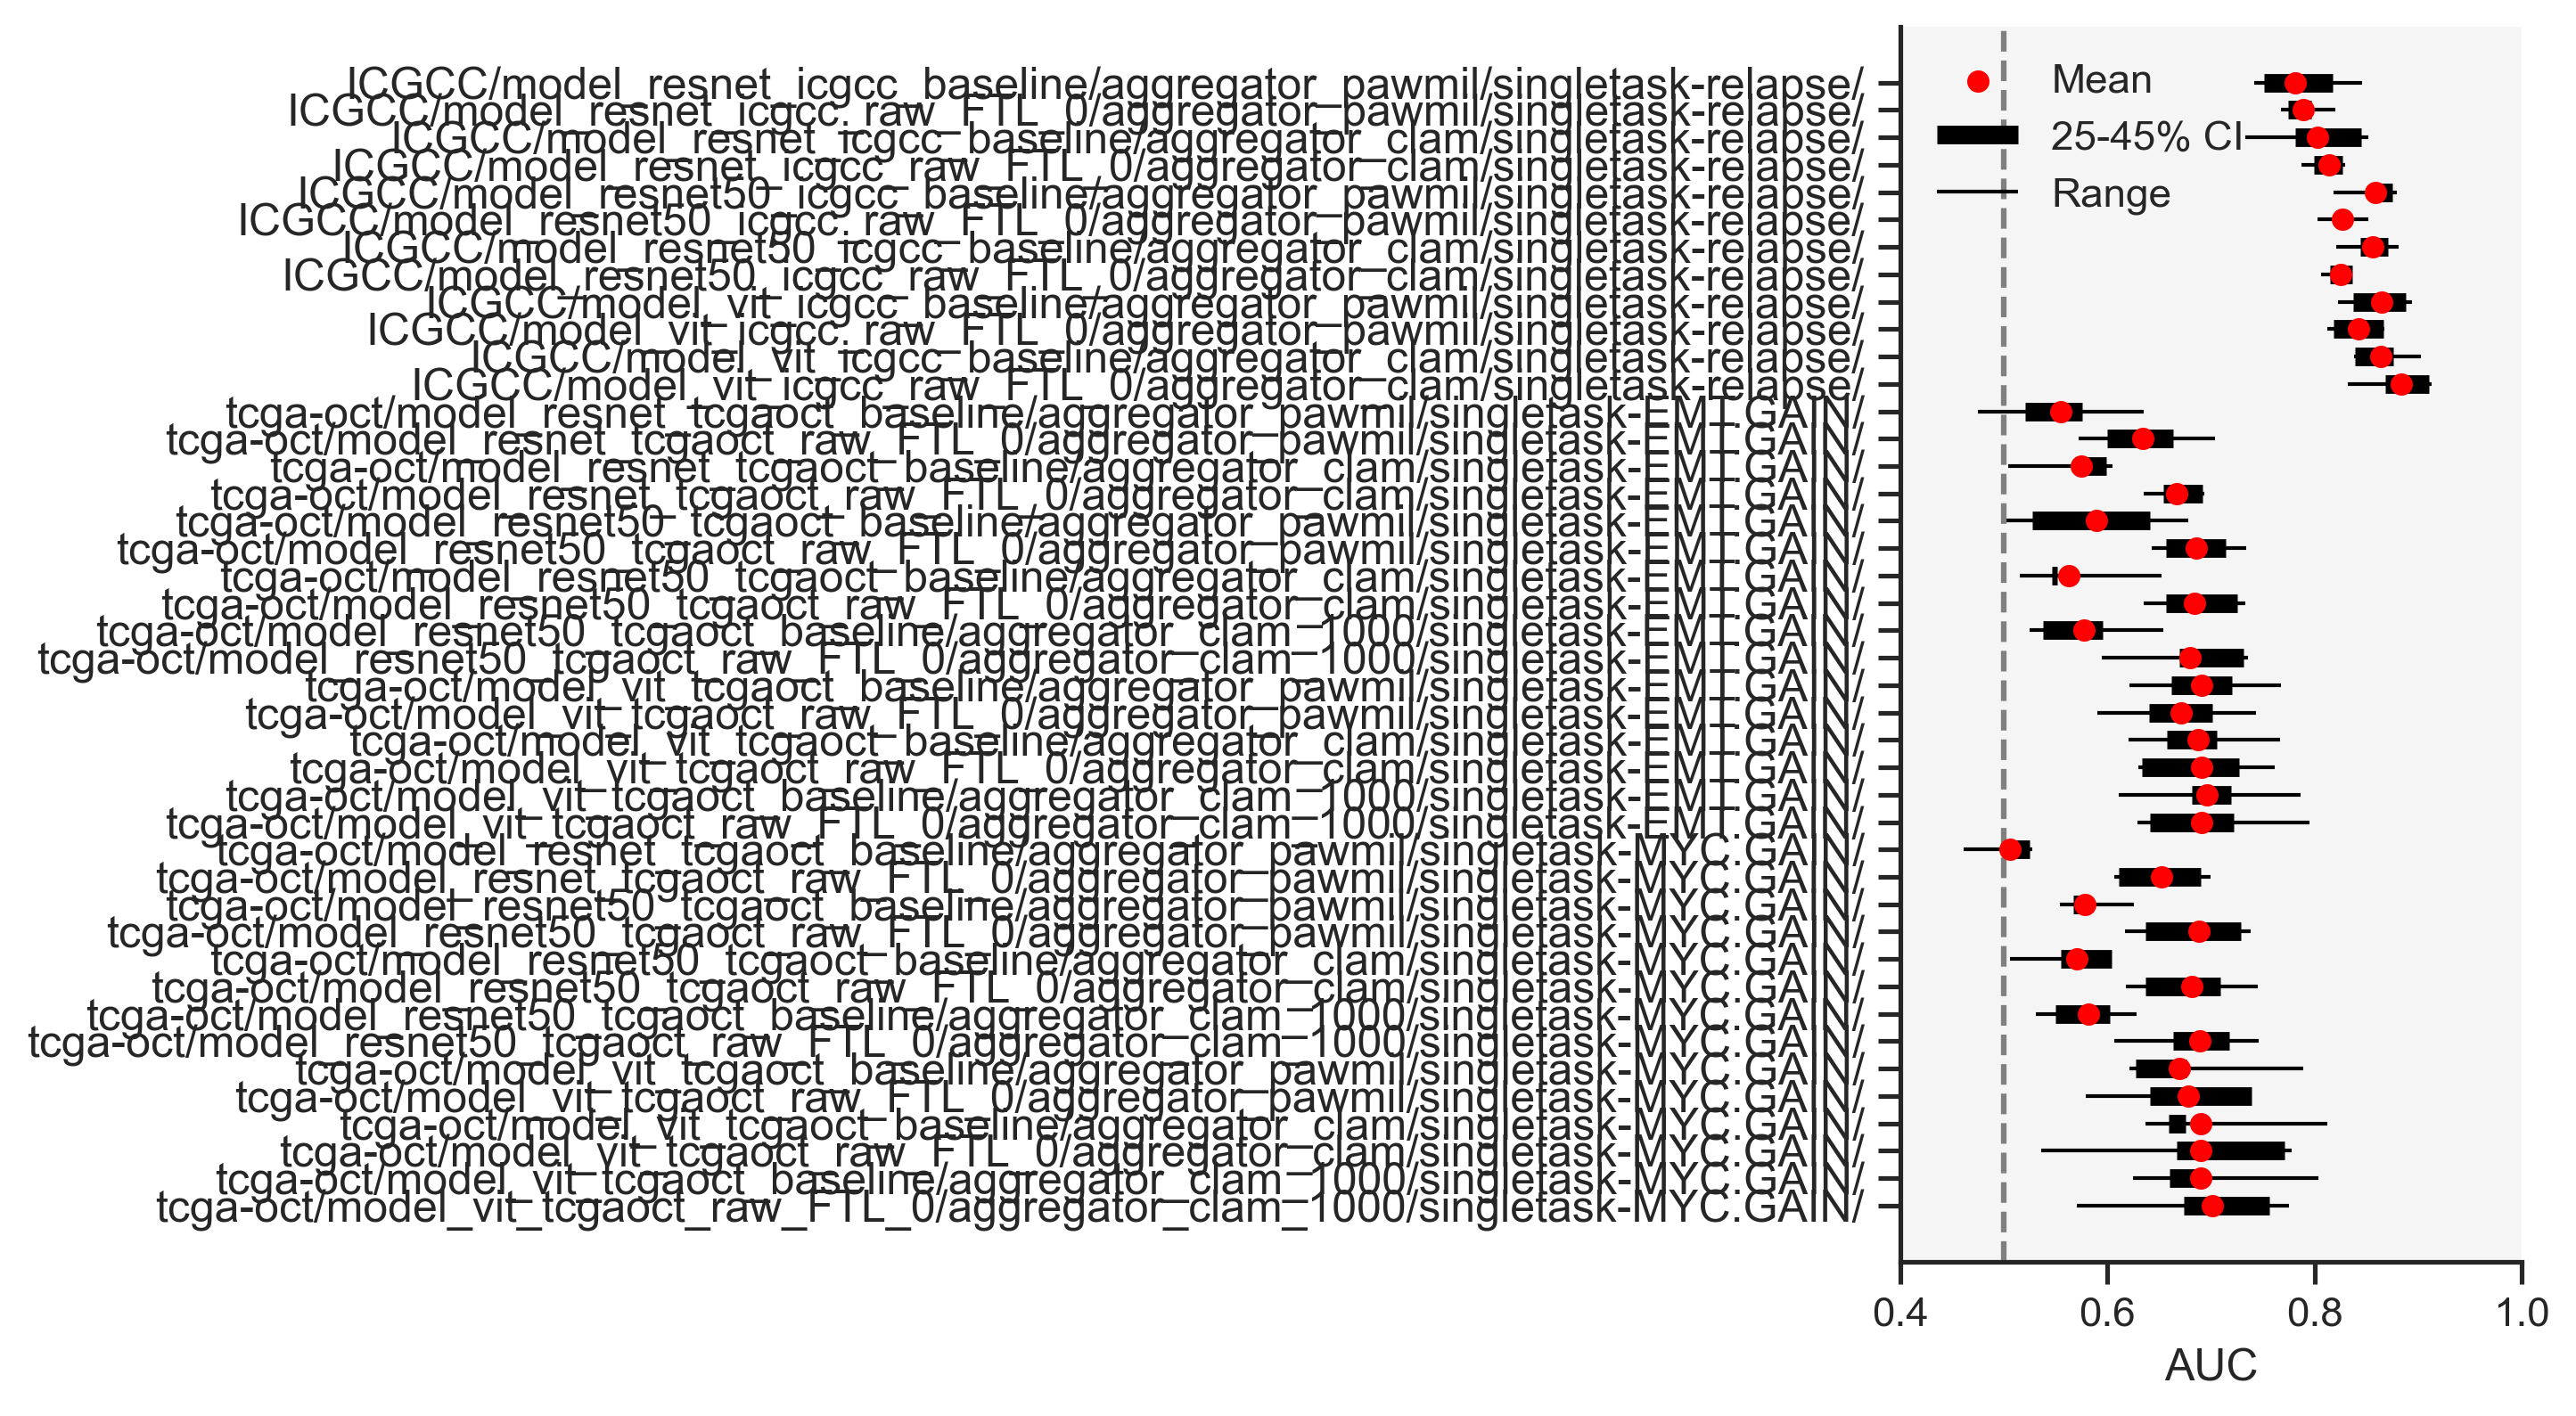

In [36]:
###################
## VISUALISATION ##
###################

## Parameters
aggregate = True
average = True
custom_labels = []
compact_labels = False

plt.figure(figsize=(3, 6))    

if aggregate == True:
    ## Aggregate folds
    labels_ = unique_preserve_order(labels)
    y = np.concatenate(all_test_data)
    if average == True:
        y = y.mean(1).reshape(-1,1) # 
    y = y.reshape(int(y.shape[0]/(5)), y.shape[1]*(5))
    x = range(y.shape[0])
else:
    ## All folds
    labels_ = labels
    y = np.concatenate(all_test_data)
    x = range(y.shape[0])

if custom_labels != []:
    labels_ = custom_labels # np.arange(len(labels_))

if compact_labels:
    labels_ = np.arange(len(labels_))

k = 0
for y_ in y:
    ## Plot individual data points (horizontal)
    # plt.scatter(y_, np.repeat(x[k], len(y_)), color='grey', alpha=0.6)
    
    ## Plot mean (horizontal)
    mean_y = np.mean(y_)
    plt.scatter(mean_y, x[k], color='red', s=25, zorder=3, label="Mean" if k == 0 else "")
    
    ## Plot median (horizontal)
    median_y = np.median(y_)
    # plt.scatter(median_y, x[k], color='blue', s=25, zorder=3, label="Median" if k == 0 else "")
    
    ## Plot interquartile range (25th to 75th percentile)
    q25, q75 = np.percentile(y_, [25, 75])
    plt.hlines(x[k], q25, q75, color='black', lw=5, label=f"25-45% CI" if k == 0 else "")

    ## Plot range (2.5th to 97.5th percentile)
    qmin, qmax = np.percentile(y_, [2.5, 97.5])
    if average == False:
        plt.hlines(x[k], qmin, qmax, color='red', lw=2, label=f"95% CI" if k == 0 else "")

    ## Plot min-max range
    plt.hlines(x[k], y_.min(), y_.max(), color='black', lw=1, label="Range" if k == 0 else "")
    
    k += 1

## Add vertical line at 0.5
plt.axvline(x=0.5, linestyle='--', color='gray')

## Set y-axis labels (reversed order)
plt.yticks(ticks=np.arange(len(labels_)), labels=labels_, rotation='horizontal', fontsize=12)

## Reverse the y-axis to maintain correct label order
plt.gca().invert_yaxis()

## Display the legend horizontally at the bottom
plt.legend(loc='upper left', frameon=False)
# plt.legend(loc='lower left', bbox_to_anchor=(0.0, 0.0), ncol=1, frameon=False)

## End
plt.tight_layout()
plt.xlabel("AUC")
plt.xlim(0.4,1.0)
plt.show()
plt.close()

#
###

In [23]:
aauc_mean = []
aauc_std = []
aauc_ci_lo = []
aauc_ci_hi = []
for y_ in y:
    avg = np.mean(y_)
    std = np.std(y_)
    qmin, qmax = np.percentile(y_, [2.5, 97.5])
    aauc_mean += [avg]
    aauc_std += [std]
    aauc_ci_lo += [qmin]
    aauc_ci_hi += [qmax]
print(np.round(aauc_mean,2))
print(np.round(aauc_std,2))

[0.78 0.79 0.8  0.81 0.86 0.83 0.86 0.83 0.86 0.84 0.86 0.88]
[0.04 0.02 0.04 0.02 0.02 0.02 0.02 0.01 0.03 0.02 0.02 0.03]


In [23]:
import math
import statistics
from itertools import combinations
from statistics import NormalDist

def paired_t_test(x, y):
    """
    Paired-sample t-test (differences).
    Returns t_statistic, p_value (approximate normal).
    """
    if len(x) != len(y):
        raise ValueError("Paired samples must have same length")
    # differences
    diffs = [xi - yi for xi, yi in zip(x, y)]
    n = len(diffs)
    mean_diff = statistics.mean(diffs)
    std_diff = statistics.pstdev(diffs)  # uses denominator (n-1)
    se = std_diff / math.sqrt(n)
    t_stat = mean_diff / se
    # approximate two-sided p via Normal CDF
    p_val = 2 * (1 - NormalDist().cdf(abs(t_stat)))
    return t_stat, p_val

def welch_t_test(x, y):
    """
    Welch’s (independent) t-test.
    Returns t_statistic, p_value (approximate normal).
    """
    n1, n2 = len(x), len(y)
    m1, m2 = statistics.mean(x), statistics.mean(y)
    s1, s2 = statistics.pstdev(x), statistics.pstdev(y)  # sample stdev
    # standard error
    se = math.sqrt( (s1*s1)/n1 + (s2*s2)/n2 )
    t_stat = (m1 - m2) / se
    # Welch–Satterthwaite degrees of freedom (not used for p here)
    df = ( (s1*s1/n1 + s2*s2/n2)**2
           / ((s1*s1/n1)**2/(n1-1) + (s2*s2/n2)**2/(n2-1)) )
    # approximate two-sided p via Normal CDF
    p_val = 2 * (1 - NormalDist().cdf(abs(t_stat)))
    return t_stat, p_val

def pairwise_t_tests(aucs, names=None, paired=True):
    """
    Perform all pairwise t-tests on a list of AUC‐value sequences.

    Parameters
    ----------
    aucs : list of list-of-floats
        e.g. [[0.82,0.85,…], [0.79,0.81,…], …]
    names : list of str, optional
        Labels for each ensemble; defaults to E1, E2, …
    paired : bool
        If True, do paired tests; else Welch independent tests.

    Returns
    -------
    results : list of dicts
        Each dict has keys:
         - 'model1','model2'
         - 't_stat','p_val'
    """
    k = len(aucs)
    if names is None:
        names = [f"E{i+1}" for i in range(k)]
    if len(names) != k:
        raise ValueError("`names` must match length of `aucs`")

    results = []
    test_fn = paired_t_test if paired else welch_t_test

    for (i, x), (j, y) in combinations(enumerate(aucs), 2):
        t_stat, p_val = test_fn(x, y)
        results.append({
            'model1': names[i],
            'model2': names[j],
            't_stat': t_stat,
            'p_val': p_val
        })

    return results

# Example usage:
if __name__ == "__main__":
    # Suppose you have 5-fold CV AUCs for three ensembles:
    AUCs = y
    print(labels)
    names = labels

    # Paired comparisons (same folds):
    res_paired = pairwise_t_tests(AUCs, names=names, paired=True)
    print("Paired t-tests:")
    for r in res_paired:
        print(f"  {r['model1']} vs {r['model2']}: "
              f"t={r['t_stat']:.3f}, p≈{r['p_val']:.3f}")

    # Welch independent comparisons:
    res_welch = pairwise_t_tests(AUCs, names=names, paired=False)
    print("\nWelch t-tests:")
    for r in res_welch:
        print(f"  {r['model1']} vs {r['model2']}: "
              f"t={r['t_stat']:.3f}, p≈{r['p_val']:.3f}")


['model_resnet_tcgaoct_baseline/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_baseline/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_baseline/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_baseline/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_baseline/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_0/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-EMT.GAIN/', 'model_resnet_tcgaoct_raw_FTL_1/aggregator/singletask-EMT.GAIN/', 'model_resnet_

ValueError: `names` must match length of `aucs`